# 05: Policy Comparison And Sensitivity

This notebook is the final technical notebook for  **Off-Policy Evaluation of Recommendation Systems**.

Notebook 3 introduced IPS and SNIPS. Notebook 4 added direct method and doubly robust OPE. Those estimates are useful, but a good offline policy recommendation should not depend on one exact modeling choice.

This notebook asks the decision-quality question:

> Are the policy conclusions stable enough to recommend a policy for online A/B testing?

We stress-test the conclusions across three dimensions:

- **weight clipping sensitivity**: do estimates change when extreme weights are capped?
- **reward model sensitivity**: do DR estimates agree across logistic regression and LightGBM?
- **time split sensitivity**: does the same policy look good across different train/evaluation windows?

The goal is not to claim that offline OPE proves a production winner. The goal is to identify the most credible candidate for online experimentation and document the remaining risks.


<!-- dataset-experiment-context -->
## Dataset and Experiment Context

This project uses the Open Bandit Dataset from a fashion e-commerce recommendation setting. Each row is a logged recommendation event with context features, the item action chosen by the behavior policy, a binary click reward, and the behavior-policy propensity for the chosen action.

The main analysis uses the `random/men` campaign because randomized logging gives broad action support and known propensities. Open Bandit also contains adaptive Bernoulli Thompson Sampling logs, but random logging is the cleanest starting point for off-policy evaluation.

The offline experiment asks which candidate recommendation policy deserves online validation. IPS, SNIPS, direct method, doubly robust estimates, effective sample size, clipping sensitivity, and reward-model diagnostics are treated as launch-readiness evidence for later online testing.

**Role of this notebook.** This notebook compares fixed policies under clipping, support, reward-model, and split-sensitivity checks to identify stable online-test candidates.

<!-- mathematical-setup -->

## Mathematical Setup

Policy comparison ranks a finite set of candidate policies \(\Pi=\{\pi_1,\ldots,\pi_K\}\). Each policy gets an estimated value and uncertainty interval,

$$
\widehat V(\pi_k) \pm 1.96\,\widehat{\operatorname{SE}}\{\widehat V(\pi_k)\}.
$$

The comparison is decision-oriented, so the notebook also looks at risk diagnostics such as effective sample size and large-weight exposure. A conservative improvement check compares a candidate policy against a baseline policy \(\pi_0\):

$$
\widehat\Delta_k=\widehat V(\pi_k)-\widehat V(\pi_0).
$$

A policy with high estimated value but weak support should be treated differently from a policy with high value and stable diagnostics.


## Project Recap

The causal setup is a logged contextual bandit problem.

For each recommendation event, we observe context `X`, logged action `A`, reward `Y`, and behavior-policy propensity `pi_b(A|X)`. We define candidate evaluation policies `pi_e` and estimate their values offline.

The estimators so far are:

- **IPS**: averages `pi_e / pi_b * Y`
- **SNIPS**: normalizes IPS weights by total weight
- **Direct Method**: averages reward model predictions under each policy
- **Doubly Robust**: direct method plus an importance-weighted residual correction

This notebook compares those estimators through the lens of stability. A policy with a slightly lower estimate but much stronger support may be a better A/B-test candidate than a policy with a high but fragile offline estimate.


#### Setup

This cell imports the libraries needed for sensitivity analysis. It also suppresses one known LightGBM/sklearn feature-name metadata warning so repeated model scoring does not clutter the notebook output.

The notebook uses the same modeling stack as Notebook 4, including logistic regression and LightGBM reward models. We keep implementation explicit so every estimate can be traced back to the formula.


In [1]:
from pathlib import Path
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)


This cell prepares the notebook environment for policy comparison and sensitivity analysis. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


#### Load The Random Open Bandit Sample

This cell loads the cached `random/men` sample used throughout the off-policy evaluation notebooks.

We keep the random log as the primary source for policy comparison because earlier notebooks showed that it has broad action support and stable logged propensities. That makes it the cleanest log for comparing evaluation policies.


In [2]:
RANDOM_SAMPLE_RELATIVE_PATH = Path("data/processed/open_bandit_random_men_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / RANDOM_SAMPLE_RELATIVE_PATH).exists()
)

RANDOM_SAMPLE_PATH = PROJECT_ROOT / RANDOM_SAMPLE_RELATIVE_PATH
random_df = pd.read_parquet(RANDOM_SAMPLE_PATH).sort_values("timestamp").reset_index(drop=True)

pd.Series(
    {
        "project_root": PROJECT_ROOT,
        "random_sample_path": RANDOM_SAMPLE_PATH,
        "rows": len(random_df),
        "columns": random_df.shape[1],
        "observed_click_rate": random_df["click"].mean(),
    }
).to_frame("value")


,value
project_root,/home/apex/Documents/portfolio
random_sample_path,/home/apex/Documents/portfolio/data/processed/...
rows,200000
columns,50
observed_click_rate,0.005190


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


#### Define Shared Feature Groups

This cell defines the action space and reward-model feature groups.

The reward model features mirror Notebook 4. The most important engineered feature is `selected_affinity`, which selects the user-item affinity column corresponding to the candidate item being scored. This lets the same feature function work for logged actions and counterfactual candidate actions.


In [3]:
# Define shared feature groups.
action_space = np.array(sorted(random_df["item_id"].unique()))
n_actions = len(action_space)

user_feature_cols = [col for col in random_df.columns if col.startswith("user_feature_")]
affinity_cols_by_action = [f"user-item_affinity_{item_id}" for item_id in action_space]
item_feature_cols = [col for col in random_df.columns if col.startswith("item_feature_")]

categorical_features = [
    "position",
    "hour",
    "item_id",
    *user_feature_cols,
    "item_feature_1",
    "item_feature_2",
    "item_feature_3",
]
numeric_features = ["selected_affinity", "item_feature_0"]
feature_cols = categorical_features + numeric_features

item_context = (
    random_df[["item_id", *item_feature_cols]]
    .drop_duplicates("item_id")
    .set_index("item_id")
    .sort_index()
)

pd.DataFrame(
    {
        "object": ["actions", "user features", "affinity columns", "item features", "model features"],
        "count": [n_actions, len(user_feature_cols), len(affinity_cols_by_action), len(item_feature_cols), len(feature_cols)],
    }
)


,object,count
0,actions,34
1,user features,4
2,affinity columns,34
3,item features,4
4,model features,12


These feature-building cells define the context used by reward models. Reward models need both user context and candidate item context so they can predict counterfactual rewards for actions that were not logged.


#### Define Reusable Feature Builders

This cell defines helper functions for reward-model feature construction.

`make_logged_feature_frame` creates features for the action that was actually logged. `make_candidate_feature_frame` creates features for every candidate action in each context row. The second function is what makes direct method and doubly robust OPE possible: it lets the reward model predict outcomes for actions we did not observe in that row.


In [4]:
# Define reusable feature builders.
def make_logged_feature_frame(df):
    """
    Create reward-model features for logged Open Bandit actions.
    
    Idea
    ----
    Each row keeps the observed context and the action actually chosen by the behavior policy, which is the training target for reward-model nuisance fits.
    
    Parameters
    ----------
    df : object
        Input data frame for the current helper.
    
    Returns
    -------
    pandas.DataFrame
        Feature frame aligned with the logged reward rows.
    """
    frame = df.copy()
    affinity_matrix = frame[affinity_cols_by_action].to_numpy()
    item_positions = frame["item_id"].map({item_id: idx for idx, item_id in enumerate(action_space)}).to_numpy()
    frame["selected_affinity"] = affinity_matrix[np.arange(len(frame)), item_positions]
    return frame[feature_cols]


def make_candidate_feature_frame(context_df):
    """
    Create reward-model features for every candidate action in each context.
    
    Idea
    ----
    This expands each context across the action space so direct-method and contextual-policy predictions can evaluate actions that were not logged on that row.
    
    Parameters
    ----------
    context_df : object
        Context rows for which candidate actions are evaluated.
    
    Returns
    -------
    pandas.DataFrame
        Long feature frame containing one row per context-action pair.
    """
    n_contexts = len(context_df)
    tiled_actions = np.tile(action_space, n_contexts)

    frame = pd.DataFrame(
        {
            "position": np.repeat(context_df["position"].to_numpy(), n_actions),
            "hour": np.repeat(context_df["hour"].to_numpy(), n_actions),
            "item_id": tiled_actions,
        }
    )

    for col in user_feature_cols:
        frame[col] = np.repeat(context_df[col].to_numpy(), n_actions)

    affinity_matrix = context_df[affinity_cols_by_action].to_numpy()
    frame["selected_affinity"] = affinity_matrix.reshape(-1)

    repeated_item_context = item_context.loc[tiled_actions, item_feature_cols].reset_index(drop=True)
    frame = pd.concat([frame, repeated_item_context], axis=1)

    return frame[feature_cols]

make_logged_feature_frame(random_df.head(3))


,position,hour,item_id,user_feature_0,user_feature_1,user_feature_2,user_feature_3,item_feature_1,item_feature_2,item_feature_3,selected_affinity,item_feature_0
0,1,0,0,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.677183
1,3,0,25,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,9874ffb54e9b0a269e29bbb2f5328735,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.461600
2,2,0,23,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,55fe518d85813954c7d9b8a875ff2453,cc75031396a5aa830885915aa93f49d0,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,-0.569392


These feature-building cells define the context used by reward models. Reward models need both user context and candidate item context so they can predict counterfactual rewards for actions that were not logged.


#### Define Evaluation Policy Builder

This helper recreates the candidate policies from Notebooks 3 and 4 using only the training split.

The candidate policies are intentionally simple:

- `uniform`: equal probability across items
- `exposure_popularity`: probability proportional to training exposure
- `ctr_weighted`: probability proportional to smoothed training CTR
- `epsilon_greedy_top_ctr`: most probability on the top smoothed-CTR item, with exploration mass elsewhere

Using the same policies keeps the notebook sequence coherent and lets us focus on sensitivity, not policy invention.


In [5]:
# Define evaluation policy builder.
def normalize_probabilities(values):
    """
    Normalize nonnegative scores into action probabilities.
    
    Idea
    ----
    The helper turns item scores into a valid evaluation-policy distribution and protects OPE estimators from zero-sum or invalid probability vectors.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    
    Returns
    -------
    numpy.ndarray
        Probability vector that sums to one.
    """
    values = np.asarray(values, dtype=float)
    values = np.clip(values, 0, None)
    total = values.sum()
    if total <= 0:
        raise ValueError("Policy scores must have positive total mass.")
    return values / total


def build_policy_probabilities(train_df, smoothing_alpha=50, epsilon=0.15):
    """
    Build fixed evaluation-policy probabilities from training logs.
    
    Idea
    ----
    The function converts empirical item performance into smoothed fixed policies so they can be evaluated on held-out Open Bandit logs.
    
    Parameters
    ----------
    train_df : object
        Training rows used to learn policies or reward models.
    smoothing_alpha : object
        Smoothing strength for empirical policy probabilities.
    epsilon : object
        Exploration probability for epsilon-greedy policies.
    
    Returns
    -------
    pandas.DataFrame
        Policy-probability table indexed by item action.
    """
    train_global_ctr = train_df["click"].mean()
    item_stats = (
        train_df.groupby("item_id")
        .agg(train_impressions=("click", "size"), train_clicks=("click", "sum"), train_ctr=("click", "mean"))
        .reindex(action_space, fill_value=0)
        .rename_axis("item_id")
        .reset_index()
    )
    item_stats["smoothed_ctr"] = (
        item_stats["train_clicks"] + smoothing_alpha * train_global_ctr
    ) / (item_stats["train_impressions"] + smoothing_alpha)
    item_stats["train_exposure_share"] = item_stats["train_impressions"] / item_stats["train_impressions"].sum()

    uniform_probs = np.full(n_actions, 1 / n_actions)
    exposure_popularity_probs = normalize_probabilities(item_stats["train_exposure_share"].to_numpy())
    ctr_weighted_probs = normalize_probabilities(item_stats["smoothed_ctr"].to_numpy())

    epsilon_greedy_probs = np.full(n_actions, epsilon / n_actions)
    top_ctr_index = int(item_stats["smoothed_ctr"].to_numpy().argmax())
    epsilon_greedy_probs[top_ctr_index] += 1 - epsilon

    policy_probability_df = pd.DataFrame(
        {
            "item_id": action_space,
            "uniform": uniform_probs,
            "exposure_popularity": exposure_popularity_probs,
            "ctr_weighted": ctr_weighted_probs,
            "epsilon_greedy_top_ctr": epsilon_greedy_probs,
        }
    )
    return item_stats, policy_probability_df


The policy definitions create several offline candidates with different levels of targeting. Comparing simple policies first makes it easier to understand IPS, SNIPS, and DR behavior before moving to contextual policies.


#### Define Reward Model Builders

This helper returns a fresh reward-model pipeline for each sensitivity run.

A fresh pipeline matters because each split should be independent. Reusing fitted preprocessors or fitted models across splits would leak information and make the sensitivity analysis less trustworthy.


In [6]:
# Define reward model builders.
def build_preprocessor():
    """
    Build the Open Bandit reward-model preprocessor.
    
    Idea
    ----
    The preprocessor handles numeric context, action, and position features so reward models receive a stable design matrix across policy comparisons.
    
    Parameters
    ----------
    None
        The function reads the project-level categorical and numeric feature lists used by the reward-model pipeline.
    
    Returns
    -------
    sklearn.compose.ColumnTransformer
        Configured preprocessing transformer for reward-model features.
    """
    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("numeric", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )


def build_reward_model(model_name):
    """
    Build a reward model for Open Bandit policy evaluation.
    
    Idea
    ----
    The helper chooses a learner family and wraps it with preprocessing so click-reward predictions can feed direct and doubly robust estimators.
    
    Parameters
    ----------
    model_name : object
        Label identifying the model family or specification.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Reward-model pipeline for the requested model family.
    """
    if model_name == "logistic":
        model = LogisticRegression(max_iter=500, solver="lbfgs")
    elif model_name == "lightgbm":
        model = lgb.LGBMClassifier(
            n_estimators=180,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=100,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=42,
            verbose=-1,
        )
    elif model_name == "lightgbm_shallow":
        model = lgb.LGBMClassifier(
            n_estimators=120,
            learning_rate=0.06,
            num_leaves=15,
            min_child_samples=200,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=42,
            verbose=-1,
        )
    else:
        raise ValueError(f"Unknown reward model: {model_name}")

    return Pipeline(steps=[("preprocess", build_preprocessor()), ("model", model)])


The preprocessing and model-builder definitions make reward modeling reusable across policies, splits, and sensitivity checks. This helps ensure that estimator differences come from policy or model choices.


#### Define OPE Helper Functions

This cell defines the estimator machinery used throughout the notebook.

The helper functions compute effective sample size, large-sample confidence intervals, IPS, SNIPS, direct method, and doubly robust estimates. They also support weight clipping for sensitivity analysis. Clipping is applied to the importance-weighted terms, not to the direct-method prediction.


In [7]:
# Define OPE helper functions.
def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.square(weights).sum()


def summarize_signal(signal):
    """
    Summarize the distribution of an OPE diagnostic signal.
    
    Idea
    ----
    The helper reports quantiles and extremes for weights, propensities, or residual terms so unstable policies are easy to spot.
    
    Parameters
    ----------
    signal : object
        Diagnostic vector to summarize.
    
    Returns
    -------
    dict
        Summary statistics for the supplied diagnostic vector.
    """
    signal = np.asarray(signal, dtype=float)
    estimate = signal.mean()
    se = signal.std(ddof=1) / np.sqrt(len(signal))
    return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se


def estimate_policy_values(reward, weight, q_logged, direct_component, clip=None):
    """
    Estimate several OPE values for one policy and clipping rule.
    
    Idea
    ----
    The helper computes IPS, SNIPS, direct-method, and doubly robust estimates so candidate policies can be compared with consistent diagnostics.
    
    Parameters
    ----------
    reward : object
        Observed logged reward values.
    weight : object
        Importance weights for the evaluation policy.
    q_logged : object
        Reward-model prediction for the logged action.
    direct_component : object
        Direct-method value component for the evaluation policy.
    clip : object
        Optional upper bound for importance weights.
    
    Returns
    -------
    pandas.DataFrame
        Policy-value estimates for the requested clipping configuration.
    """
    reward = np.asarray(reward, dtype=float)
    raw_weight = np.asarray(weight, dtype=float)
    weight = raw_weight if clip is None else np.minimum(raw_weight, clip)
    q_logged = np.asarray(q_logged, dtype=float)
    direct_component = np.asarray(direct_component, dtype=float)

    ips_signal = weight * reward
    ips = summarize_signal(ips_signal)

    snips_estimate = ips_signal.sum() / weight.sum()
    snips_influence = weight * (reward - snips_estimate) / weight.mean()
    snips_se = snips_influence.std(ddof=1) / np.sqrt(len(snips_influence))
    snips = (snips_estimate, snips_se, snips_estimate - 1.96 * snips_se, snips_estimate + 1.96 * snips_se)

    dm = summarize_signal(direct_component)
    correction = weight * (reward - q_logged)
    dr_signal = direct_component + correction
    dr = summarize_signal(dr_signal)

    return {
        "IPS": ips,
        "SNIPS": snips,
        "DM": dm,
        "DR": dr,
        "ess_share": effective_sample_size(weight) / len(weight),
        "mean_weight": weight.mean(),
        "max_weight": weight.max(),
        "p99_weight": np.percentile(weight, 99),
        "mean_abs_correction": np.abs(correction).mean(),
        "mean_correction": correction.mean(),
    }


The helper functions encode the estimator formulas and diagnostics used repeatedly in the notebook. Defining them once keeps the later policy comparisons consistent and easier to audit.


#### Define Candidate-Action Scoring Helper

This helper computes direct-method components for every policy in batches.

For each evaluation context, it predicts `q_hat(x, a)` for all candidate actions. It then multiplies those predictions by each policy's action probabilities. The output is one direct-method component per context and policy.


In [8]:
# Define candidate-action scoring helper.
def compute_direct_components(model, contexts_df, policy_probability_df, batch_size=12_000):
    """
    Compute direct-method value components for candidate policies.
    
    Idea
    ----
    The function predicts rewards for every context-action pair, weights those predictions by policy probabilities, and returns one model-based value component per context.
    
    Parameters
    ----------
    model : object
        Fitted or unfitted model used in the helper.
    contexts_df : object
        Context rows for which candidate actions are evaluated.
    policy_probability_df : object
        Candidate policy probabilities for each action.
    batch_size : object
        Number of rows to score in each prediction batch.
    
    Returns
    -------
    pandas.DataFrame
        Direct-method components aligned with evaluation contexts and policies.
    """
    policy_cols = [col for col in policy_probability_df.columns if col != "item_id"]
    policy_probability_matrix = policy_probability_df[policy_cols].to_numpy()
    component_batches = []

    for start in range(0, len(contexts_df), batch_size):
        context_batch = contexts_df.iloc[start : start + batch_size]
        candidate_features = make_candidate_feature_frame(context_batch)
        q_hat = model.predict_proba(candidate_features)[:, 1].reshape(len(context_batch), n_actions)
        component_batches.append(q_hat @ policy_probability_matrix)

    components = np.vstack(component_batches)
    return pd.DataFrame(components, columns=policy_cols, index=contexts_df.index)


These cells score candidate actions under the reward model, which is what lets the direct method estimate values for policies that choose actions different from the logged one. This is the model-based complement to importance weighting.


#### Define One End-To-End Evaluation Function

This cell defines the core analysis function used by the sensitivity sections.

For a given train/evaluation split and reward model, it:

1. builds evaluation policies from the training split
2. trains a reward model on logged training rows
3. scores logged evaluation rows
4. scores all candidate actions for direct method
5. computes IPS, SNIPS, DM, and DR estimates
6. returns policy estimates, reward-model metrics, and policy probabilities

Having this in one function reduces copy-paste risk across the sensitivity analysis.


In [9]:
# Define one end-to-end evaluation function.
def run_ope_for_split(train_df, eval_df, model_name="lightgbm", split_name="main", clip=None):
    """
    Run the full OPE workflow on one train/evaluation split.
    
    Idea
    ----
    The function trains reward models, builds fixed policy probabilities, computes direct components, and returns OPE estimates for a held-out split.
    
    Parameters
    ----------
    train_df : object
        Training rows used to learn policies or reward models.
    eval_df : object
        Evaluation rows used for held-out OPE.
    model_name : object
        Label identifying the model family or specification.
    split_name : object
        Label for the current train/evaluation split.
    clip : object
        Optional upper bound for importance weights.
    
    Returns
    -------
    pandas.DataFrame
        Policy-value estimates and diagnostics for the requested split.
    """
    item_stats, policy_probability_df = build_policy_probabilities(train_df)
    policy_cols = [col for col in policy_probability_df.columns if col != "item_id"]

    X_train = make_logged_feature_frame(train_df)
    y_train = train_df["click"].astype(int)
    X_eval_logged = make_logged_feature_frame(eval_df)
    y_eval = eval_df["click"].astype(int)

    model = build_reward_model(model_name)
    model.fit(X_train, y_train)

    q_logged = model.predict_proba(X_eval_logged)[:, 1]
    direct_components = compute_direct_components(model, eval_df, policy_probability_df)

    model_metrics = {
        "split_name": split_name,
        "reward_model": model_name,
        "train_rows": len(train_df),
        "eval_rows": len(eval_df),
        "auc": roc_auc_score(y_eval, q_logged),
        "average_precision": average_precision_score(y_eval, q_logged),
        "log_loss": log_loss(y_eval, q_logged, labels=[0, 1]),
        "brier_score": brier_score_loss(y_eval, q_logged),
        "mean_prediction": q_logged.mean(),
        "observed_click_rate": y_eval.mean(),
    }

    eval_scored = eval_df[["timestamp", "item_id", "position", "click", "propensity_score"]].copy()
    result_rows = []
    reward = eval_scored["click"].to_numpy()

    for policy in policy_cols:
        probability_map = policy_probability_df.set_index("item_id")[policy]
        pi_e = eval_scored["item_id"].map(probability_map).to_numpy()
        weight = pi_e / eval_scored["propensity_score"].to_numpy()
        estimates = estimate_policy_values(
            reward=reward,
            weight=weight,
            q_logged=q_logged,
            direct_component=direct_components[policy].to_numpy(),
            clip=clip,
        )

        for estimator in ["IPS", "SNIPS", "DM", "DR"]:
            estimate, se, lower, upper = estimates[estimator]
            result_rows.append(
                {
                    "split_name": split_name,
                    "reward_model": model_name,
                    "policy": policy,
                    "estimator": estimator,
                    "clip": "none" if clip is None else clip,
                    "estimate": estimate,
                    "se": se,
                    "ci_95_lower": lower,
                    "ci_95_upper": upper,
                    "ess_share": estimates["ess_share"],
                    "mean_weight": estimates["mean_weight"],
                    "max_weight": estimates["max_weight"],
                    "p99_weight": estimates["p99_weight"],
                    "mean_abs_correction": estimates["mean_abs_correction"],
                    "mean_correction": estimates["mean_correction"],
                    "eval_observed_click_rate": y_eval.mean(),
                }
            )

    return pd.DataFrame(result_rows), pd.DataFrame([model_metrics]), policy_probability_df, item_stats


The end-to-end evaluation function packages splitting, reward modeling, policy scoring, and OPE estimation into one repeatable workflow. This makes sensitivity analysis possible without rewriting estimator logic each time.


#### Create The Main Split

This cell recreates the primary 50/50 time split from Notebooks 3 and 4.

The main split is used for detailed clipping and reward-model sensitivity. Later, split sensitivity uses several shorter evaluation windows to test whether conclusions hold across time.


In [10]:
MAIN_SPLIT_FRACTION = 0.50
main_split_idx = int(len(random_df) * MAIN_SPLIT_FRACTION)

main_train_df = random_df.iloc[:main_split_idx].copy()
main_eval_df = random_df.iloc[main_split_idx:].copy()

main_split_summary = pd.DataFrame(
    {
        "split": ["train", "evaluation"],
        "rows": [len(main_train_df), len(main_eval_df)],
        "min_timestamp": [main_train_df["timestamp"].min(), main_eval_df["timestamp"].min()],
        "max_timestamp": [main_train_df["timestamp"].max(), main_eval_df["timestamp"].max()],
        "click_rate": [main_train_df["click"].mean(), main_eval_df["click"].mean()],
    }
)

main_split_summary


,split,rows,min_timestamp,max_timestamp,click_rate
0,train,100000,2019-11-24 00:00:03.800821+00:00,2019-11-25 10:01:18.392921+00:00,0.005400
1,evaluation,100000,2019-11-25 10:01:18.393450+00:00,2019-11-27 02:50:16.027289+00:00,0.004980


The split separates policy construction from policy evaluation. This prevents using the same rows to design a policy and evaluate it, which would make the offline result too optimistic.


### Main LightGBM OPE Estimates

This cell runs the main OPE estimate using the LightGBM reward model and no weight clipping.

This is the baseline result that the sensitivity sections will stress-test. It includes IPS, SNIPS, direct method, and doubly robust estimates for every candidate policy.


In [11]:
main_lgbm_estimates, main_lgbm_metrics, main_policy_probability_df, main_item_stats = run_ope_for_split(
    main_train_df,
    main_eval_df,
    model_name="lightgbm",
    split_name="main_50_50",
    clip=None,
)

main_lgbm_metrics


,split_name,reward_model,train_rows,eval_rows,auc,average_precision,log_loss,brier_score,mean_prediction,observed_click_rate
0,main_50_50,lightgbm,100000,100000,0.534265,0.005821,0.034100,0.005096,0.004932,0.004980


The main LightGBM OPE estimates serve as the reference result for policy comparison. Later sensitivity checks ask whether the same policy ranking survives changes in clipping, reward model, and time split.


#### Main Estimate Table

This cell displays the main LightGBM estimates. The table is sorted by estimator and estimated value so the strongest policies under each estimator are easy to inspect.

The main comparison to watch is between IPS/SNIPS and DR. If they agree directionally, that strengthens confidence. If they disagree, the final recommendation should be more cautious.


In [12]:
main_lgbm_table = main_lgbm_estimates.copy()
main_lgbm_table["lift_pp"] = 100 * (main_lgbm_table["estimate"] - main_lgbm_table["eval_observed_click_rate"])
main_lgbm_table["relative_lift_pct"] = 100 * (
    main_lgbm_table["estimate"] / main_lgbm_table["eval_observed_click_rate"] - 1
)

main_lgbm_table.sort_values(["estimator", "estimate"], ascending=[True, False])


,split_name,reward_model,policy,estimator,clip,estimate,se,ci_95_lower,ci_95_upper,ess_share,mean_weight,max_weight,p99_weight,mean_abs_correction,mean_correction,eval_observed_click_rate,lift_pp,relative_lift_pct
14,main_50_50,lightgbm,epsilon_greedy_top_ctr,DM,none,0.011638,0.000065,0.011510,0.011765,0.040290,1.001105,29.050000,29.050000,0.017369,-0.005016,0.004980,0.665769,133.688460
10,main_50_50,lightgbm,ctr_weighted,DM,none,0.006048,0.000016,0.006017,0.006078,0.790628,0.996987,2.740842,2.740842,0.011042,-0.000766,0.004980,0.106781,21.441995
2,main_50_50,lightgbm,uniform,DM,none,0.004986,0.000013,0.004961,0.005010,1.000000,1.000000,1.000000,1.000000,0.009856,0.000048,0.004980,0.000564,0.113302
6,main_50_50,lightgbm,exposure_popularity,DM,none,0.004956,0.000013,0.004931,0.004980,0.996399,1.000591,1.132200,1.132200,0.009821,0.000064,0.004980,-0.002441,-0.490126
15,main_50_50,lightgbm,epsilon_greedy_top_ctr,DR,none,0.006622,0.001320,0.004035,0.009209,0.040290,1.001105,29.050000,29.050000,0.017369,-0.005016,0.004980,0.164171,32.966042
11,main_50_50,lightgbm,ctr_weighted,DR,none,0.005282,0.000267,0.004759,0.005805,0.790628,0.996987,2.740842,2.740842,0.011042,-0.000766,0.004980,0.030172,6.058681
3,main_50_50,lightgbm,uniform,DR,none,0.005034,0.000226,0.004592,0.005476,1.000000,1.000000,1.000000,1.000000,0.009856,0.000048,0.004980,0.005411,1.086540
7,main_50_50,lightgbm,exposure_popularity,DR,none,0.005020,0.000226,0.004578,0.005462,0.996399,1.000591,1.132200,1.132200,0.009821,0.000064,0.004980,0.003997,0.802658
12,main_50_50,lightgbm,epsilon_greedy_top_ctr,IPS,none,0.006238,0.001267,0.003756,0.008720,0.040290,1.001105,29.050000,29.050000,0.017369,-0.005016,0.004980,0.125800,25.261044
8,main_50_50,lightgbm,ctr_weighted,IPS,none,0.005172,0.000261,0.004660,0.005685,0.790628,0.996987,2.740842,2.740842,0.011042,-0.000766,0.004980,0.019244,3.864167


The reshaped table puts policy values, uncertainty, and diagnostics into a comparison-friendly format. This is the table that later plots and recommendation decisions build from. The important comparison is which policy remains credible after support, uncertainty, and operational constraints are considered.


#### Plot Main Policy Estimates

This plot compares IPS, SNIPS, and DR estimates from the main split. Direct method is omitted from this plot so the visual stays focused on estimators that use logged propensities.

The confidence intervals are approximate large-sample intervals. They should be read as uncertainty diagnostics, not as a final product decision by themselves.


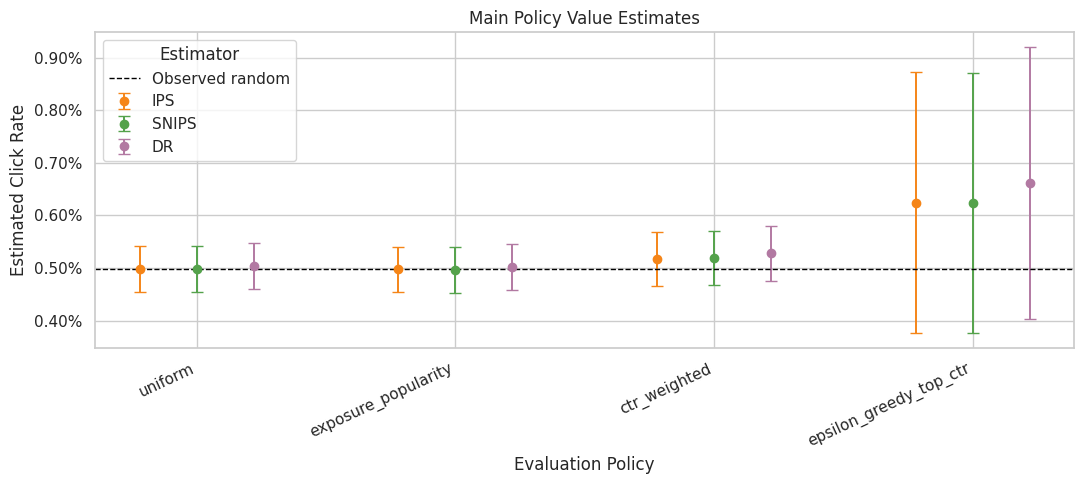

In [13]:
# Plot main policy estimates.
main_plot = main_lgbm_table.query("estimator in ['IPS', 'SNIPS', 'DR']").copy()
main_plot["lower_error"] = main_plot["estimate"] - main_plot["ci_95_lower"]
main_plot["upper_error"] = main_plot["ci_95_upper"] - main_plot["estimate"]

policy_order = main_plot["policy"].drop_duplicates().tolist()
estimator_order = ["IPS", "SNIPS", "DR"]
offsets = {"IPS": -0.22, "SNIPS": 0.0, "DR": 0.22}
colors = {"IPS": "#F58518", "SNIPS": "#54A24B", "DR": "#B279A2"}

fig, ax = plt.subplots(figsize=(11, 5))
for estimator in estimator_order:
    subset = main_plot[main_plot["estimator"] == estimator]
    for _, row in subset.iterrows():
        x_base = policy_order.index(row["policy"])
        x = x_base + offsets[estimator]
        ax.errorbar(
            x=x,
            y=row["estimate"],
            yerr=[[row["lower_error"]], [row["upper_error"]]],
            fmt="o",
            color=colors[estimator],
            ecolor=colors[estimator],
            capsize=4,
            linewidth=1.4,
            markersize=6,
            label=estimator if row["policy"] == subset["policy"].iloc[0] else None,
        )

ax.axhline(main_eval_df["click"].mean(), color="black", linestyle="--", linewidth=1, label="Observed random")
ax.set_xticks(range(len(policy_order)))
ax.set_xticklabels(policy_order, rotation=25, ha="right")
ax.set_title("Main Policy Value Estimates")
ax.set_xlabel("Evaluation Policy")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
ax.legend(title="Estimator")
plt.tight_layout()
plt.show()


The estimate plot compares policies on the same offline value scale. Error bars and estimator differences are just as important as the ranking, because high-variance estimates should not drive product decisions alone.


### Weight Clipping Sensitivity

This section checks whether conclusions depend on extreme importance weights.

We estimate the same policies with no clipping and with weight caps at 5, 10, and 20. Clipping can reduce variance, but it also changes the estimand by shrinking the influence of rare high-weight rows. A robust policy conclusion should not flip wildly across reasonable clipping thresholds.


In [14]:
clip_values = [None, 5, 10, 20]
clipping_frames = []
for clip in clip_values:
    estimates, metrics, _, _ = run_ope_for_split(
        main_train_df,
        main_eval_df,
        model_name="lightgbm",
        split_name="main_50_50",
        clip=clip,
    )
    clipping_frames.append(estimates)

clipping_sensitivity = pd.concat(clipping_frames, ignore_index=True)
clipping_sensitivity["lift_pp"] = 100 * (
    clipping_sensitivity["estimate"] - clipping_sensitivity["eval_observed_click_rate"]
)

clipping_sensitivity.query("estimator in ['IPS', 'SNIPS', 'DR']").head(12)


,split_name,reward_model,policy,estimator,clip,estimate,se,ci_95_lower,ci_95_upper,ess_share,mean_weight,max_weight,p99_weight,mean_abs_correction,mean_correction,eval_observed_click_rate,lift_pp
0,main_50_50,lightgbm,uniform,IPS,none,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000,1.000000,0.009856,0.000048,0.004980,0.000000
1,main_50_50,lightgbm,uniform,SNIPS,none,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000,1.000000,0.009856,0.000048,0.004980,0.000000
3,main_50_50,lightgbm,uniform,DR,none,0.005034,0.000226,0.004592,0.005476,1.000000,1.000000,1.000000,1.000000,0.009856,0.000048,0.004980,0.005411
4,main_50_50,lightgbm,exposure_popularity,IPS,none,0.004971,0.000223,0.004535,0.005407,0.996399,1.000591,1.132200,1.132200,0.009821,0.000064,0.004980,-0.000904
5,main_50_50,lightgbm,exposure_popularity,SNIPS,none,0.004968,0.000223,0.004532,0.005404,0.996399,1.000591,1.132200,1.132200,0.009821,0.000064,0.004980,-0.001198
7,main_50_50,lightgbm,exposure_popularity,DR,none,0.005020,0.000226,0.004578,0.005462,0.996399,1.000591,1.132200,1.132200,0.009821,0.000064,0.004980,0.003997
8,main_50_50,lightgbm,ctr_weighted,IPS,none,0.005172,0.000261,0.004660,0.005685,0.790628,0.996987,2.740842,2.740842,0.011042,-0.000766,0.004980,0.019244
9,main_50_50,lightgbm,ctr_weighted,SNIPS,none,0.005188,0.000262,0.004675,0.005701,0.790628,0.996987,2.740842,2.740842,0.011042,-0.000766,0.004980,0.020806
11,main_50_50,lightgbm,ctr_weighted,DR,none,0.005282,0.000267,0.004759,0.005805,0.790628,0.996987,2.740842,2.740842,0.011042,-0.000766,0.004980,0.030172
12,main_50_50,lightgbm,epsilon_greedy_top_ctr,IPS,none,0.006238,0.001267,0.003756,0.008720,0.040290,1.001105,29.050000,29.050000,0.017369,-0.005016,0.004980,0.125800


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Plot Clipping Sensitivity

This plot shows how the estimated policy value changes as the clipping threshold changes.

The most important line is the DR line, because DR is the preferred estimator after Notebook 4. IPS is included to show why clipping matters more for pure importance weighting. SNIPS is included as a stabilizing benchmark.


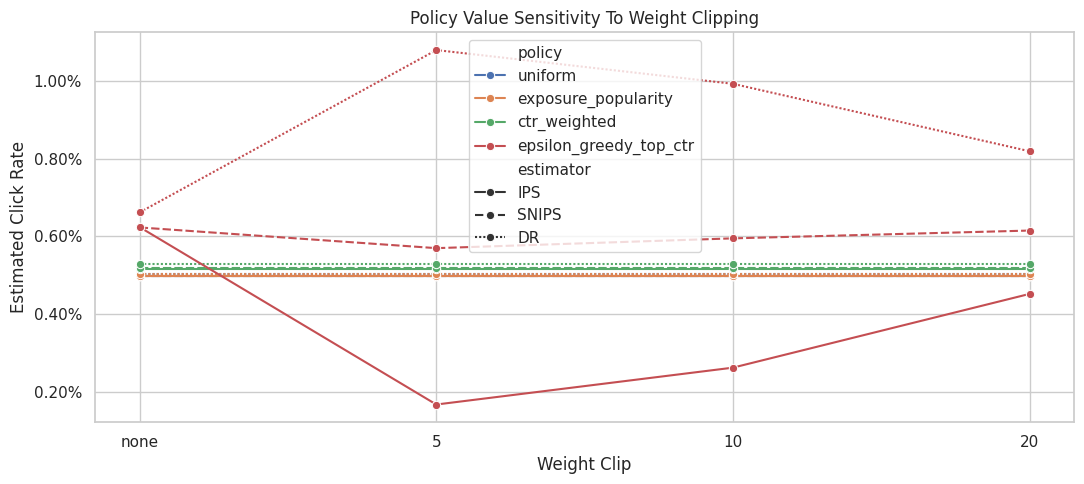

In [15]:
clipping_plot = clipping_sensitivity.query("estimator in ['IPS', 'SNIPS', 'DR']").copy()
clipping_plot["clip_label"] = clipping_plot["clip"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=clipping_plot,
    x="clip_label",
    y="estimate",
    hue="policy",
    style="estimator",
    marker="o",
    ax=ax,
)
ax.set_title("Policy Value Sensitivity To Weight Clipping")
ax.set_xlabel("Weight Clip")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
plt.tight_layout()
plt.show()


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Clipping Stability Summary

This cell summarizes how much each policy-estimator estimate moves across clipping thresholds.

`estimate_range` is the difference between the largest and smallest estimate across the clipping settings. Smaller ranges indicate more stable estimates. Large ranges indicate that extreme weights are influencing the result.


In [16]:
clipping_stability = (
    clipping_sensitivity.query("estimator in ['IPS', 'SNIPS', 'DR']")
    .groupby(["policy", "estimator"])
    .agg(
        min_estimate=("estimate", "min"),
        max_estimate=("estimate", "max"),
        estimate_range=("estimate", lambda x: x.max() - x.min()),
        min_ess_share=("ess_share", "min"),
        max_weight=("max_weight", "max"),
    )
    .reset_index()
    .sort_values("estimate_range", ascending=False)
)

clipping_stability


,policy,estimator,min_estimate,max_estimate,estimate_range,min_ess_share,max_weight
4,epsilon_greedy_top_ctr,IPS,0.001669,0.006238,0.004570,0.040290,29.050000
3,epsilon_greedy_top_ctr,DR,0.006622,0.010802,0.004180,0.040290,29.050000
5,epsilon_greedy_top_ctr,SNIPS,0.005698,0.006231,0.000533,0.040290,29.050000
0,ctr_weighted,DR,0.005282,0.005282,0.000000,0.790628,2.740842
2,ctr_weighted,SNIPS,0.005188,0.005188,0.000000,0.790628,2.740842
1,ctr_weighted,IPS,0.005172,0.005172,0.000000,0.790628,2.740842
6,exposure_popularity,DR,0.005020,0.005020,0.000000,0.996399,1.132200
7,exposure_popularity,IPS,0.004971,0.004971,0.000000,0.996399,1.132200
8,exposure_popularity,SNIPS,0.004968,0.004968,0.000000,0.996399,1.132200
9,uniform,DR,0.005034,0.005034,0.000000,1.000000,1.000000


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


### Reward Model Sensitivity

This section checks whether doubly robust estimates depend heavily on the reward model.

We compare three reward-model specifications:

- logistic regression
- a shallow LightGBM model
- the main LightGBM model

If DR estimates are broadly consistent across these models, that supports the policy conclusion. If rankings change sharply, the final recommendation should be framed as more tentative.


In [17]:
reward_model_names = ["logistic", "lightgbm_shallow", "lightgbm"]
reward_model_estimate_frames = []
reward_model_metric_frames = []

for model_name in reward_model_names:
    estimates, metrics, _, _ = run_ope_for_split(
        main_train_df,
        main_eval_df,
        model_name=model_name,
        split_name="main_50_50",
        clip=None,
    )
    reward_model_estimate_frames.append(estimates)
    reward_model_metric_frames.append(metrics)

reward_model_sensitivity = pd.concat(reward_model_estimate_frames, ignore_index=True)
reward_model_metrics = pd.concat(reward_model_metric_frames, ignore_index=True)

reward_model_metrics.sort_values("log_loss")


,split_name,reward_model,train_rows,eval_rows,auc,average_precision,log_loss,brier_score,mean_prediction,observed_click_rate
0,main_50_50,logistic,100000,100000,0.539928,0.006395,0.032528,0.005081,0.005774,0.004980
1,main_50_50,lightgbm_shallow,100000,100000,0.541724,0.006571,0.032535,0.005020,0.005315,0.004980
2,main_50_50,lightgbm,100000,100000,0.534265,0.005821,0.034100,0.005096,0.004932,0.004980


Reward-model sensitivity checks whether DR conclusions depend on a particular predictive model. Stable rankings across model classes make the recommendation more credible. In OPE, this diagnostic determines whether a target policy is being evaluated from real logged support or from a few high-leverage coincidences.


#### Plot Reward Model Sensitivity For DR

This plot compares DR estimates across reward models.

The DR estimator still uses the same logged propensities and the same evaluation policies. The only changing ingredient is the reward model used for the direct component and residual prediction. Stable DR estimates across models are a good sign.


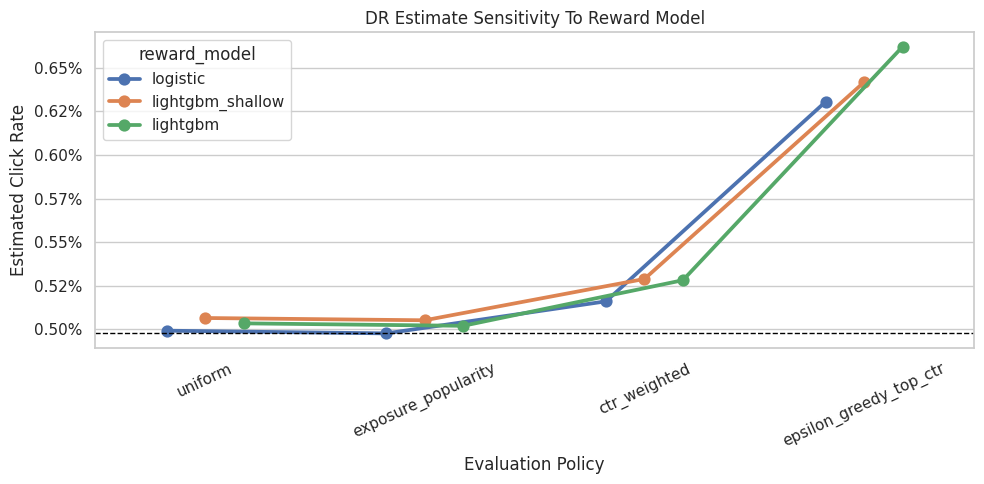

In [18]:
dr_model_plot = reward_model_sensitivity.query("estimator == 'DR'").copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(
    data=dr_model_plot,
    x="policy",
    y="estimate",
    hue="reward_model",
    dodge=0.35,
    errorbar=None,
    ax=ax,
)
ax.axhline(main_eval_df["click"].mean(), color="black", linestyle="--", linewidth=1, label="Observed random")
ax.set_title("DR Estimate Sensitivity To Reward Model")
ax.set_xlabel("Evaluation Policy")
ax.set_ylabel("Estimated Click Rate")
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
plt.tight_layout()
plt.show()


Reward-model sensitivity checks whether DR conclusions depend on a particular predictive model. Stable rankings across model classes make the recommendation more credible. The important comparison is which policy remains credible after support, uncertainty, and operational constraints are considered.


#### Reward Model Ranking Stability

This cell converts reward-model sensitivity into policy ranks.

Rank 1 is the highest DR estimate within a reward model. If the same policy remains near the top across reward models, the recommendation is more robust. If the top policy changes completely, we should be cautious.


In [19]:
reward_model_rank_stability = dr_model_plot.copy()
reward_model_rank_stability["rank_within_model"] = reward_model_rank_stability.groupby("reward_model")["estimate"].rank(
    ascending=False, method="min"
)

reward_model_rank_summary = (
    reward_model_rank_stability.groupby("policy")
    .agg(
        avg_rank_across_models=("rank_within_model", "mean"),
        best_rank_across_models=("rank_within_model", "min"),
        worst_rank_across_models=("rank_within_model", "max"),
        estimate_range_across_models=("estimate", lambda x: x.max() - x.min()),
    )
    .reset_index()
    .sort_values(["avg_rank_across_models", "estimate_range_across_models"])
)

reward_model_rank_summary


,policy,avg_rank_across_models,best_rank_across_models,worst_rank_across_models,estimate_range_across_models
1,epsilon_greedy_top_ctr,1.000000,1.000000,1.000000,0.000315
0,ctr_weighted,2.000000,2.000000,2.000000,0.000128
3,uniform,3.000000,3.000000,3.000000,0.000073
2,exposure_popularity,4.000000,4.000000,4.000000,0.000075


The stability summary focuses on whether policy rankings change under reasonable analysis choices. A policy that remains near the top across checks is a stronger offline candidate than one that wins only under one specification.


### Time Split Sensitivity

This section repeats the DR analysis across different time windows.

Each split uses an earlier block of data for training and a later block for evaluation. This tests whether the best policy is stable across time or whether it only looks good in one particular held-out window.

To keep runtime reasonable, the evaluation windows are shorter than the main 50/50 evaluation split.


In [20]:
split_specs = [
    {"split_name": "early_window", "train_start": 0.00, "train_end": 0.40, "eval_start": 0.40, "eval_end": 0.55},
    {"split_name": "middle_window", "train_start": 0.00, "train_end": 0.50, "eval_start": 0.50, "eval_end": 0.65},
    {"split_name": "late_window", "train_start": 0.00, "train_end": 0.60, "eval_start": 0.60, "eval_end": 0.75},
]

split_plan = []
for spec in split_specs:
    n = len(random_df)
    train_start = int(n * spec["train_start"])
    train_end = int(n * spec["train_end"])
    eval_start = int(n * spec["eval_start"])
    eval_end = int(n * spec["eval_end"])
    split_plan.append(
        {
            "split_name": spec["split_name"],
            "train_rows": train_end - train_start,
            "eval_rows": eval_end - eval_start,
            "train_start_time": random_df.iloc[train_start]["timestamp"],
            "train_end_time": random_df.iloc[train_end - 1]["timestamp"],
            "eval_start_time": random_df.iloc[eval_start]["timestamp"],
            "eval_end_time": random_df.iloc[eval_end - 1]["timestamp"],
        }
    )

pd.DataFrame(split_plan)


,split_name,train_rows,eval_rows,train_start_time,train_end_time,eval_start_time,eval_end_time
0,early_window,80000,30000,2019-11-24 00:00:03.800821+00:00,2019-11-25 01:13:20.340362+00:00,2019-11-25 01:13:23.467887+00:00,2019-11-25 12:31:38.942417+00:00
1,middle_window,100000,30000,2019-11-24 00:00:03.800821+00:00,2019-11-25 10:01:18.392921+00:00,2019-11-25 10:01:18.393450+00:00,2019-11-25 19:24:35.095071+00:00
2,late_window,120000,30000,2019-11-24 00:00:03.800821+00:00,2019-11-25 14:22:22.600427+00:00,2019-11-25 14:22:22.600570+00:00,2019-11-26 06:51:42.575935+00:00


Time-split sensitivity checks whether the offline conclusion changes across different train/evaluation windows. This is important because recommendation environments can drift over time. The result should be read together with support diagnostics because a good reward model cannot fully rescue evaluation when the logging policy rarely explored the relevant actions.


### Split Sensitivity Estimates

This cell runs LightGBM DR estimates for each time split.

The split loop rebuilds policies and retrains the reward model inside each time window. That is intentional because it tests the full workflow.


In [21]:
split_estimate_frames = []
split_metric_frames = []

for spec in split_specs:
    n = len(random_df)
    train_df = random_df.iloc[int(n * spec["train_start"]) : int(n * spec["train_end"])].copy()
    eval_df = random_df.iloc[int(n * spec["eval_start"]) : int(n * spec["eval_end"])].copy()

    estimates, metrics, _, _ = run_ope_for_split(
        train_df,
        eval_df,
        model_name="lightgbm",
        split_name=spec["split_name"],
        clip=None,
    )
    split_estimate_frames.append(estimates)
    split_metric_frames.append(metrics)

split_sensitivity = pd.concat(split_estimate_frames, ignore_index=True)
split_model_metrics = pd.concat(split_metric_frames, ignore_index=True)

split_model_metrics


,split_name,reward_model,train_rows,eval_rows,auc,average_precision,log_loss,brier_score,mean_prediction,observed_click_rate
0,early_window,lightgbm,80000,30000,0.540994,0.004299,0.027959,0.004138,0.004624,0.003967
1,middle_window,lightgbm,100000,30000,0.572556,0.009731,0.034497,0.005294,0.005305,0.005167
2,late_window,lightgbm,120000,30000,0.507023,0.006752,0.036425,0.005458,0.004942,0.005367


Time-split sensitivity checks whether the offline conclusion changes across different train/evaluation windows. This is important because recommendation environments can drift over time. In OPE, this diagnostic determines whether a target policy is being evaluated from real logged support or from a few high-leverage coincidences.


#### Plot Split Sensitivity For DR

This plot shows DR estimates across time windows.

A stable policy should remain competitive across early, middle, and late windows. A policy that only wins in one split may still be interesting, but it is a weaker candidate for a confident offline recommendation.


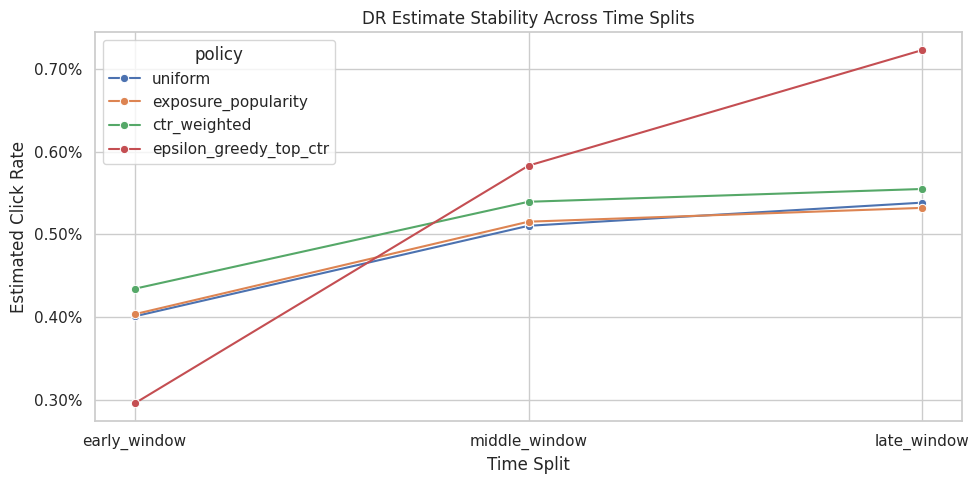

In [22]:
split_dr_plot = split_sensitivity.query("estimator == 'DR'").copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=split_dr_plot,
    x="split_name",
    y="estimate",
    hue="policy",
    marker="o",
    ax=ax,
)
ax.set_title("DR Estimate Stability Across Time Splits")
ax.set_xlabel("Time Split")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
plt.tight_layout()
plt.show()


Time-split sensitivity checks whether the offline conclusion changes across different train/evaluation windows. This is important because recommendation environments can drift over time. The important comparison is which policy remains credible after support, uncertainty, and operational constraints are considered.


#### Split Ranking Stability

This cell ranks policies within each time split using the LightGBM DR estimate.

The rank summary is more robust than staring only at point estimates. A policy with average rank near 1 and low rank standard deviation is a stable offline winner.


In [23]:
split_rank_table = split_dr_plot.copy()
split_rank_table["rank_within_split"] = split_rank_table.groupby("split_name")["estimate"].rank(
    ascending=False, method="min"
)

split_rank_summary = (
    split_rank_table.groupby("policy")
    .agg(
        avg_rank_across_splits=("rank_within_split", "mean"),
        rank_std_across_splits=("rank_within_split", "std"),
        best_rank_across_splits=("rank_within_split", "min"),
        worst_rank_across_splits=("rank_within_split", "max"),
        mean_dr_estimate_across_splits=("estimate", "mean"),
        dr_estimate_range_across_splits=("estimate", lambda x: x.max() - x.min()),
    )
    .reset_index()
    .sort_values(["avg_rank_across_splits", "dr_estimate_range_across_splits"])
)

split_rank_summary


,policy,avg_rank_across_splits,rank_std_across_splits,best_rank_across_splits,worst_rank_across_splits,mean_dr_estimate_across_splits,dr_estimate_range_across_splits
0,ctr_weighted,1.666667,0.577350,1.000000,2.000000,0.005094,0.001205
1,epsilon_greedy_top_ctr,2.000000,1.732051,1.000000,4.000000,0.005338,0.004269
2,exposure_popularity,3.000000,1.000000,2.000000,4.000000,0.004836,0.001285
3,uniform,3.333333,0.577350,3.000000,4.000000,0.004831,0.001374


The split separates policy construction from policy evaluation. This prevents using the same rows to design a policy and evaluate it, which would make the offline result too optimistic.


### Policy Risk Table

This cell combines the main LightGBM DR estimate with support, clipping stability, reward-model stability, and split stability.

This is the most decision-oriented table in the notebook. It tries to answer: which policy has strong estimated value and enough stability to justify an online experiment?


In [24]:
# Build a policy risk table.
main_dr = main_lgbm_table.query("estimator == 'DR'").copy()
main_dr = main_dr[
    [
        "policy",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "ess_share",
        "mean_weight",
        "max_weight",
        "p99_weight",
        "mean_abs_correction",
    ]
]

clip_dr_stability = clipping_stability.query("estimator == 'DR'")[["policy", "estimate_range"]].rename(
    columns={"estimate_range": "dr_clip_estimate_range"}
)

policy_risk_table = (
    main_dr.merge(clip_dr_stability, on="policy", how="left")
    .merge(reward_model_rank_summary, on="policy", how="left")
    .merge(split_rank_summary, on="policy", how="left")
)

policy_risk_table["decision_score"] = (
    policy_risk_table["lift_pp"]
    - 0.25 * policy_risk_table["avg_rank_across_splits"]
    - 100 * policy_risk_table["dr_clip_estimate_range"]
    - 0.10 * policy_risk_table["max_weight"]
)

policy_risk_table.sort_values("decision_score", ascending=False)


,policy,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,ess_share,mean_weight,max_weight,p99_weight,mean_abs_correction,dr_clip_estimate_range,avg_rank_across_models,best_rank_across_models,worst_rank_across_models,estimate_range_across_models,avg_rank_across_splits,rank_std_across_splits,best_rank_across_splits,worst_rank_across_splits,mean_dr_estimate_across_splits,dr_estimate_range_across_splits,decision_score
2,ctr_weighted,0.005282,0.004759,0.005805,0.030172,6.058681,0.790628,0.996987,2.740842,2.740842,0.011042,0.000000,2.000000,2.000000,2.000000,0.000128,1.666667,0.577350,1.000000,2.000000,0.005094,0.001205,-0.660579
1,exposure_popularity,0.005020,0.004578,0.005462,0.003997,0.802658,0.996399,1.000591,1.132200,1.132200,0.009821,0.000000,4.000000,4.000000,4.000000,0.000075,3.000000,1.000000,2.000000,4.000000,0.004836,0.001285,-0.859223
0,uniform,0.005034,0.004592,0.005476,0.005411,1.086540,1.000000,1.000000,1.000000,1.000000,0.009856,0.000000,3.000000,3.000000,3.000000,0.000073,3.333333,0.577350,3.000000,4.000000,0.004831,0.001374,-0.927922
3,epsilon_greedy_top_ctr,0.006622,0.004035,0.009209,0.164171,32.966042,0.040290,1.001105,29.050000,29.050000,0.017369,0.004180,1.000000,1.000000,1.000000,0.000315,2.000000,1.732051,1.000000,4.000000,0.005338,0.004269,-3.658854


The policy-risk table combines value, lift, support, and stability into a decision-oriented view. This is closer to how an experimentation team would decide what is safe enough to test online.


#### Choose An Offline Candidate For A/B Testing

This cell selects a candidate policy using the policy risk table.

The selection is intentionally conservative. It does not simply choose the highest point estimate. It sorts by a decision score that rewards estimated lift and penalizes poor split rank, clipping instability, and large maximum weights.

This is not an automated production rule. It is a transparent way to make the offline recommendation auditable.


In [25]:
recommended_policy_row = policy_risk_table.sort_values("decision_score", ascending=False).iloc[0]
recommended_policy = recommended_policy_row["policy"]

recommendation_summary = pd.Series(
    {
        "recommended_policy_for_ab_test": recommended_policy,
        "dr_estimated_click_rate": recommended_policy_row["estimate"],
        "lift_pp_vs_random_behavior": recommended_policy_row["lift_pp"],
        "relative_lift_pct_vs_random_behavior": recommended_policy_row["relative_lift_pct"],
        "ess_share": recommended_policy_row["ess_share"],
        "max_weight": recommended_policy_row["max_weight"],
        "avg_rank_across_splits": recommended_policy_row["avg_rank_across_splits"],
        "avg_rank_across_reward_models": recommended_policy_row["avg_rank_across_models"],
        "decision_score": recommended_policy_row["decision_score"],
    }
).to_frame("value")

recommendation_summary


,value
recommended_policy_for_ab_test,ctr_weighted
dr_estimated_click_rate,0.005282
lift_pp_vs_random_behavior,0.030172
relative_lift_pct_vs_random_behavior,6.058681
ess_share,0.790628
max_weight,2.740842
avg_rank_across_splits,1.666667
avg_rank_across_reward_models,2.000000
decision_score,-0.660579


The recommended candidate is selected from the offline evidence, not from value alone. The decision should balance estimated improvement against support risk, uncertainty, and robustness. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


## Claim Boundaries

Offline policy evaluation can identify candidate policies that deserve further testing, but it cannot prove that a policy will win after deployment. The strongest recommendation is a supported shortlist: policies with favorable estimated value, adequate logged support, acceptable weight risk, and stable conclusions across reward models and time splits.

Policies with high estimated value but poor support should remain unresolved. They may be worth collecting more data for, but they should not be treated as ready-to-launch decisions from the offline evidence alone.


In [26]:
interpretation_text = f"""
Recommended offline candidate: {recommended_policy}

Why this policy is credible:
- It has a competitive LightGBM doubly robust estimate on the main held-out split.
- Its effective sample size and maximum weight are part of the decision table, so the recommendation is not based on point estimate alone.
- It was compared across clipping thresholds, reward-model choices, and time windows.

Boundary of this evidence:
- It identifies a policy candidate for production testing.
- Long-term user effects, novelty fatigue, marketplace effects, and item interference remain outside this offline estimate.
- It assumes the Open Bandit logged propensities are correct and that the random log has support for the evaluation policies.

Operational recommendation:
Use this policy as the strongest offline candidate for an online A/B test, with guardrail metrics for click quality, downstream engagement, and user experience.
""".strip()

print(interpretation_text)


Recommended offline candidate: ctr_weighted

Why this policy is credible:
- It has a competitive LightGBM doubly robust estimate on the main held-out split.
- Its effective sample size and maximum weight are part of the decision table, so the recommendation is not based on point estimate alone.
- It was compared across clipping thresholds, reward-model choices, and time windows.

Boundary of this evidence:
- It identifies a policy candidate for production testing.
- Long-term user effects, novelty fatigue, marketplace effects, and item interference remain outside this offline estimate.
- It assumes the Open Bandit logged propensities are correct and that the random log has support for the evaluation policies.

Operational recommendation:
Use this policy as the strongest offline candidate for an online A/B test, with guardrail metrics for click quality, downstream engagement, and user experience.


This text cell states the boundary of the offline evidence. Offline evaluation can recommend candidates for online testing, but it cannot replace an A/B test when business-critical deployment decisions are at stake.


#### Save Sensitivity Tables

This final code cell saves the most important sensitivity outputs to a small writeup folder inside the off-policy evaluation notebook directory.

These tables make it easier to build a final report later without rerunning the full notebook every time.


In [27]:
WRITEUP_DIR = PROJECT_ROOT / "notebooks/projects/project_2_off_policy_evaluation/writeup"
TABLE_DIR = WRITEUP_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

main_lgbm_table.to_csv(TABLE_DIR / "main_lgbm_ope_estimates.csv", index=False)
clipping_stability.to_csv(TABLE_DIR / "clipping_stability.csv", index=False)
reward_model_rank_summary.to_csv(TABLE_DIR / "reward_model_rank_stability.csv", index=False)
split_rank_summary.to_csv(TABLE_DIR / "split_rank_stability.csv", index=False)
policy_risk_table.to_csv(TABLE_DIR / "policy_risk_table.csv", index=False)

artifact_table = pd.DataFrame(
    {
        "path": [str(path.relative_to(PROJECT_ROOT)) for path in sorted(TABLE_DIR.glob("*.csv"))],
        "size_kb": [path.stat().st_size / 1024 for path in sorted(TABLE_DIR.glob("*.csv"))],
    }
)

artifact_table


,path,size_kb
0,notebooks/projects/project_2_off_policy_evalua...,1.876953
1,notebooks/projects/project_2_off_policy_evalua...,1.283203
2,notebooks/projects/project_2_off_policy_evalua...,0.702148
3,notebooks/projects/project_2_off_policy_evalua...,0.830078
4,notebooks/projects/project_2_off_policy_evalua...,1.428711
5,notebooks/projects/project_2_off_policy_evalua...,6.987305
6,notebooks/projects/project_2_off_policy_evalua...,1.569336
7,notebooks/projects/project_2_off_policy_evalua...,0.751953
8,notebooks/projects/project_2_off_policy_evalua...,0.915039
9,notebooks/projects/project_2_off_policy_evalua...,4.750000


This cell saves reusable outputs for downstream notebooks or the final report. Persisting these artifacts makes the project modular and prevents later notebooks from repeating expensive or fragile setup work.


## Takeaways and Next Step

This notebook stress-tested the policy recommendation across estimators and sensitivity checks.

The decision process now includes:

- main LightGBM DR estimates
- IPS and SNIPS benchmarks
- clipping sensitivity
- reward-model sensitivity
- time-split sensitivity
- policy support diagnostics
- a policy risk table

The final offline output should be framed as: **which policy is most justified for an online A/B test**, not which policy is guaranteed to be best in production.

A good next step would be a short final report notebook that turns the off-policy evaluation results into clean figures, tables, and clear final-report text.
